In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set(style="whitegrid")

In [4]:
nav = pd.read_csv("../data/processed/clean_nav.csv")
transactions = pd.read_csv("../data/processed/clean_transactions.csv")
performance = pd.read_csv("../data/processed/clean_performance.csv")

print("NAV:", nav.shape)
print("Transactions:", transactions.shape)
print("Performance:", performance.shape)

NAV: (46000, 3)
Transactions: (32778, 13)
Performance: (40, 20)


In [5]:
nav['date'] = pd.to_datetime(nav['date'])
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])

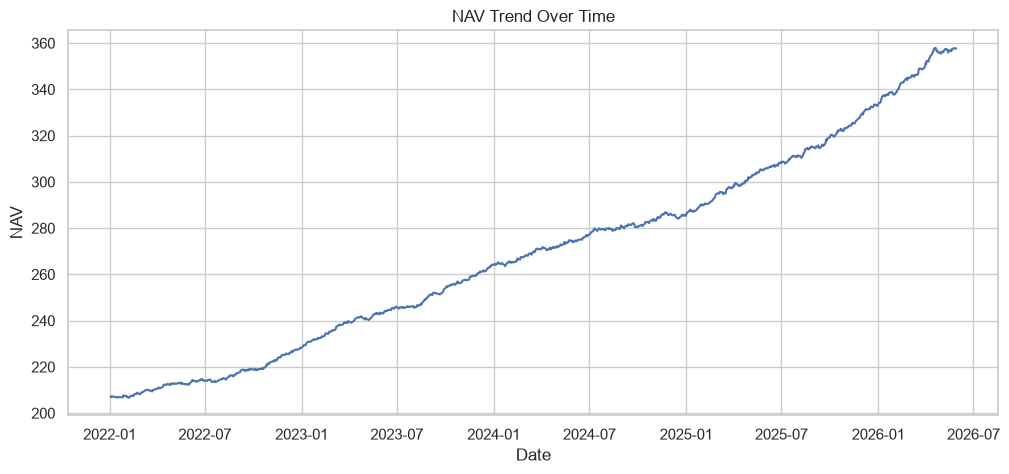

In [6]:
nav_grouped = nav.groupby('date')['nav'].mean().reset_index()

plt.figure(figsize=(12,5))
plt.plot(nav_grouped['date'], nav_grouped['nav'])
plt.title("NAV Trend Over Time")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.show()

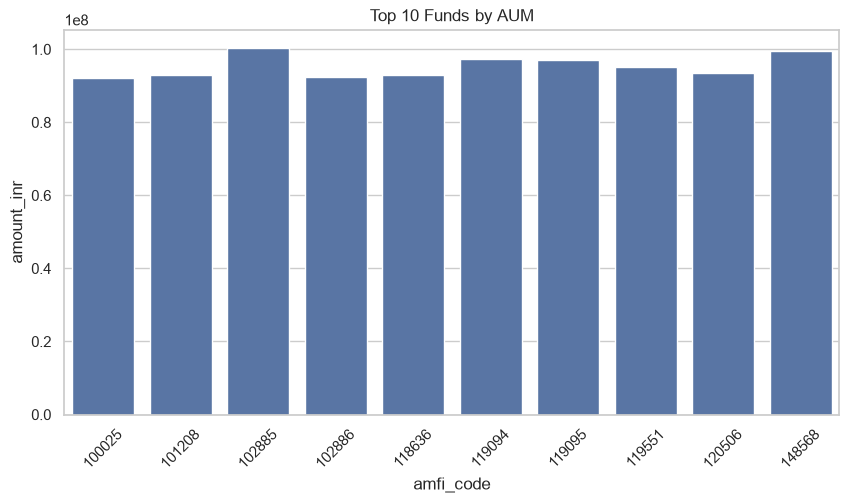

In [7]:
aum = transactions.groupby('amfi_code')['amount_inr'].sum().reset_index()
aum = aum.sort_values('amount_inr', ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(data=aum, x='amfi_code', y='amount_inr')
plt.title("Top 10 Funds by AUM")
plt.xticks(rotation=45)
plt.show()

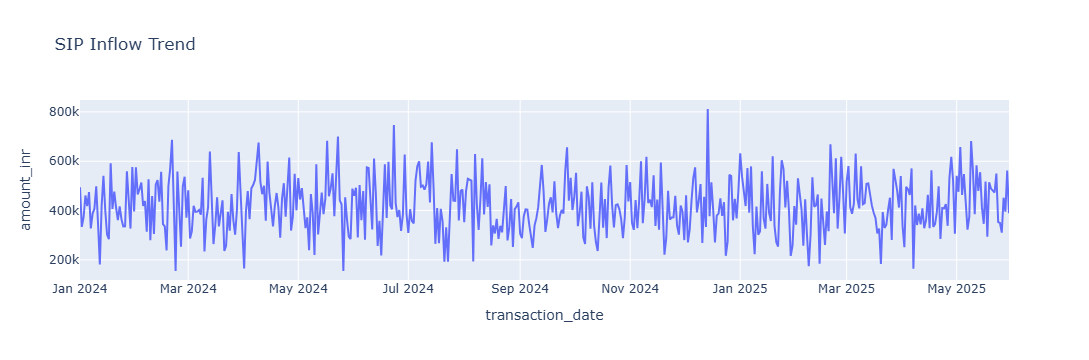

In [8]:
sip = transactions[transactions['transaction_type'] == 'SIP']

sip_trend = sip.groupby('transaction_date')['amount_inr'].sum().reset_index()

fig = px.line(sip_trend, x='transaction_date', y='amount_inr',
              title="SIP Inflow Trend")
fig.show()

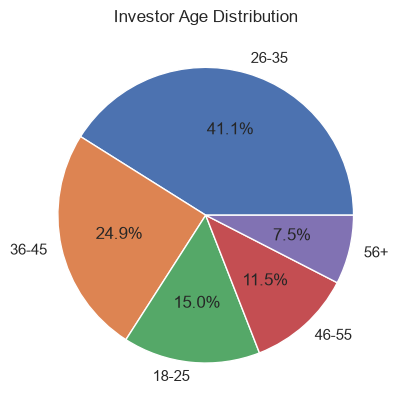

In [9]:
transactions['age_group'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Investor Age Distribution")
plt.show()

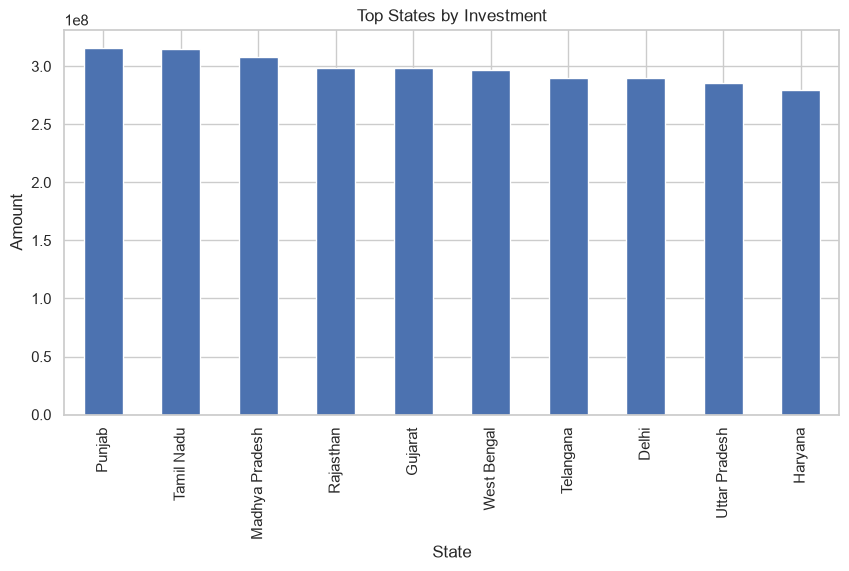

In [10]:
state = transactions.groupby('state')['amount_inr'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
state.plot(kind='bar')
plt.title("Top States by Investment")
plt.xlabel("State")
plt.ylabel("Amount")
plt.show()

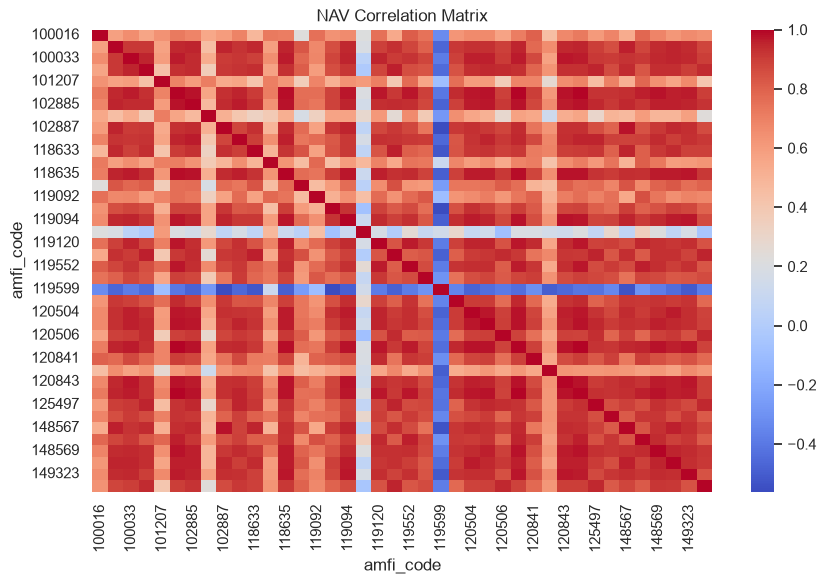

In [11]:
pivot = nav.pivot_table(index='date', columns='amfi_code', values='nav')

corr = pivot.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, cmap='coolwarm')
plt.title("NAV Correlation Matrix")
plt.show()

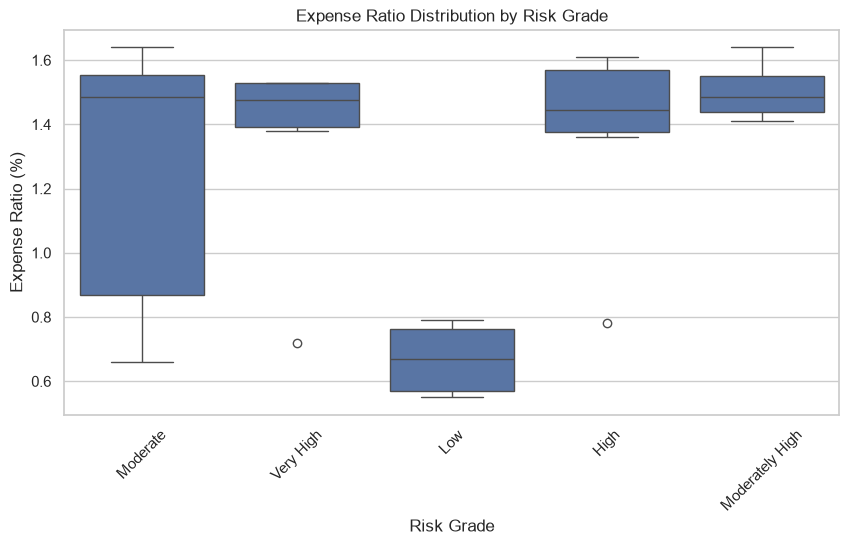

In [17]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=performance,
    x='risk_grade',
    y='expense_ratio_pct'
)

plt.title("Expense Ratio Distribution by Risk Grade")
plt.xlabel("Risk Grade")
plt.ylabel("Expense Ratio (%)")
plt.xticks(rotation=45)
plt.show()

# Key Insights

1. NAV shows long-term growth trend with small corrections.
2. SIP inflows are consistently increasing over time.
3. Large-cap funds dominate AUM contribution.
4. Younger investors prefer SIP investing.
5. Investments are concentrated in top states.
6. Funds show strong correlation within categories.
7. Market cycles impact NAV movement.
8. High-income groups invest higher amounts.
9. Equity funds show higher volatility.
10. SIP is the most preferred investment mode.